In [1]:
import sys, os
sys.path.insert(0, '../../utils')

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.ticker import FormatStrFormatter, PercentFormatter
from utils import load_neurons_table, load_synapses_position_transformed
from connectome_types import CONNECTOME_SYN_TABLE_PATH, CONNECTOME_PRE_SYN_TABLE_PATH, SPINE_TABLE_OUTGOING
from neuron_custom_features import calc_spines_features
from spines_utils import filter_valid_neuron_w_spines, split_syn_mat_by_type_four
from plot_utils import ex_color
from stats_corr import add_log_curve
from spine_pref_utils import per_neuron_spine_ratio, build_subnet_spine_ratio_df

In [3]:
neurons_df = load_neurons_table()
syn_df = load_synapses_position_transformed(base_syn_table_path=CONNECTOME_SYN_TABLE_PATH)
df, syn_with_tags = calc_spines_features(neurons_df, syn_df)
neuron_clf_type = df[['root_id', 'clf_type']].set_index('root_id').to_dict(orient='index')
df, filtered_syn_mat, filtered_bin_mat, filtered_mapping, filtered_reverse_mapping, ex_neurons, inh_neurons = filter_valid_neuron_w_spines(df)

spine_df_outgoing = pd.read_csv(SPINE_TABLE_OUTGOING)
outgoing_syn_df = load_synapses_position_transformed(base_syn_table_path=CONNECTOME_PRE_SYN_TABLE_PATH)
outgoing_syn_with_tags = outgoing_syn_df[outgoing_syn_df.id_.isin(spine_df_outgoing.target_id)].copy()
outgoing_syn_with_tags['tag'] = outgoing_syn_with_tags.id_.map(spine_df_outgoing.set_index('target_id').tag)

EE, EI, IE, II, ex_idx, inh_idx = split_syn_mat_by_type_four(filtered_bin_mat, filtered_mapping, neuron_clf_type)

ex_syn_tags = syn_with_tags[syn_with_tags.pre_clf_type == 'E']
ex_outgoing_syn_with_tags = outgoing_syn_with_tags[outgoing_syn_with_tags.pre_clf_type == 'E']

connectome neurons table:  1351
valid neurons w position: 1351
spine table incoming size (4567647, 4)
spine table outgoing size (819832, 4)
neurons: 1351
synapses with tags: 145356


100%|██████████| 1351/1351 [00:13<00:00, 100.41it/s]


Filtering neurons with valid spine data...
Remaining neurons after filtering: 1298
fixing networks
Filtering: Reducing matrix from 1351 to 1298 neurons.


In [4]:
main_feature = 'spine'

e_all_stats = per_neuron_spine_ratio(ex_syn_tags, ex_neurons.root_id.tolist())
ex_neurons = ex_neurons.copy()
ex_neurons[f'outgoing_{main_feature}_ratio_all'] = ex_neurons.root_id.map(e_all_stats['ratio'])

df_EE = build_subnet_spine_ratio_df(EE, ex_idx, ex_idx, filtered_mapping, 'E', 'E', syn_with_tags, ex_neurons)

# compute E/(E+I) ratio and total E+I syn count per neuron
df_EE['ei_outgoing_ratio_norm'] = df_EE.apply(
    lambda row: row['num_of_ex_outgoing_synapses'] / (row['num_of_inh_outgoing_synapses'] + row['num_of_ex_outgoing_synapses'])
    if (row['num_of_inh_outgoing_synapses'] + row['num_of_ex_outgoing_synapses']) != 0 else np.nan, axis=1)
df_EE['n_syn_to_EI'] = df_EE['num_of_ex_outgoing_synapses'] + df_EE['num_of_inh_outgoing_synapses']

df_EE = df_EE.rename(columns={f'outgoing_{main_feature}_ratio_all': 'outgoing_spine_ratio_all'})

In [5]:
plt.rcParams['font.size'] = 13
plt.rcParams['font.family'] = 'Arial'

spiny_color  = '#7C3AED'
aspiny_color = '#059669'
scatter_overlay_fontsize = 11

high_deg_nodes = [864691135617152361, 864691136177632518]

 log fit: a=0.0337, b=0.4099
ρ=0.20, p=p=5.0e-12
 log fit: a=0.6568, b=0.2758
ρ=0.56, p=p=2.3e-94


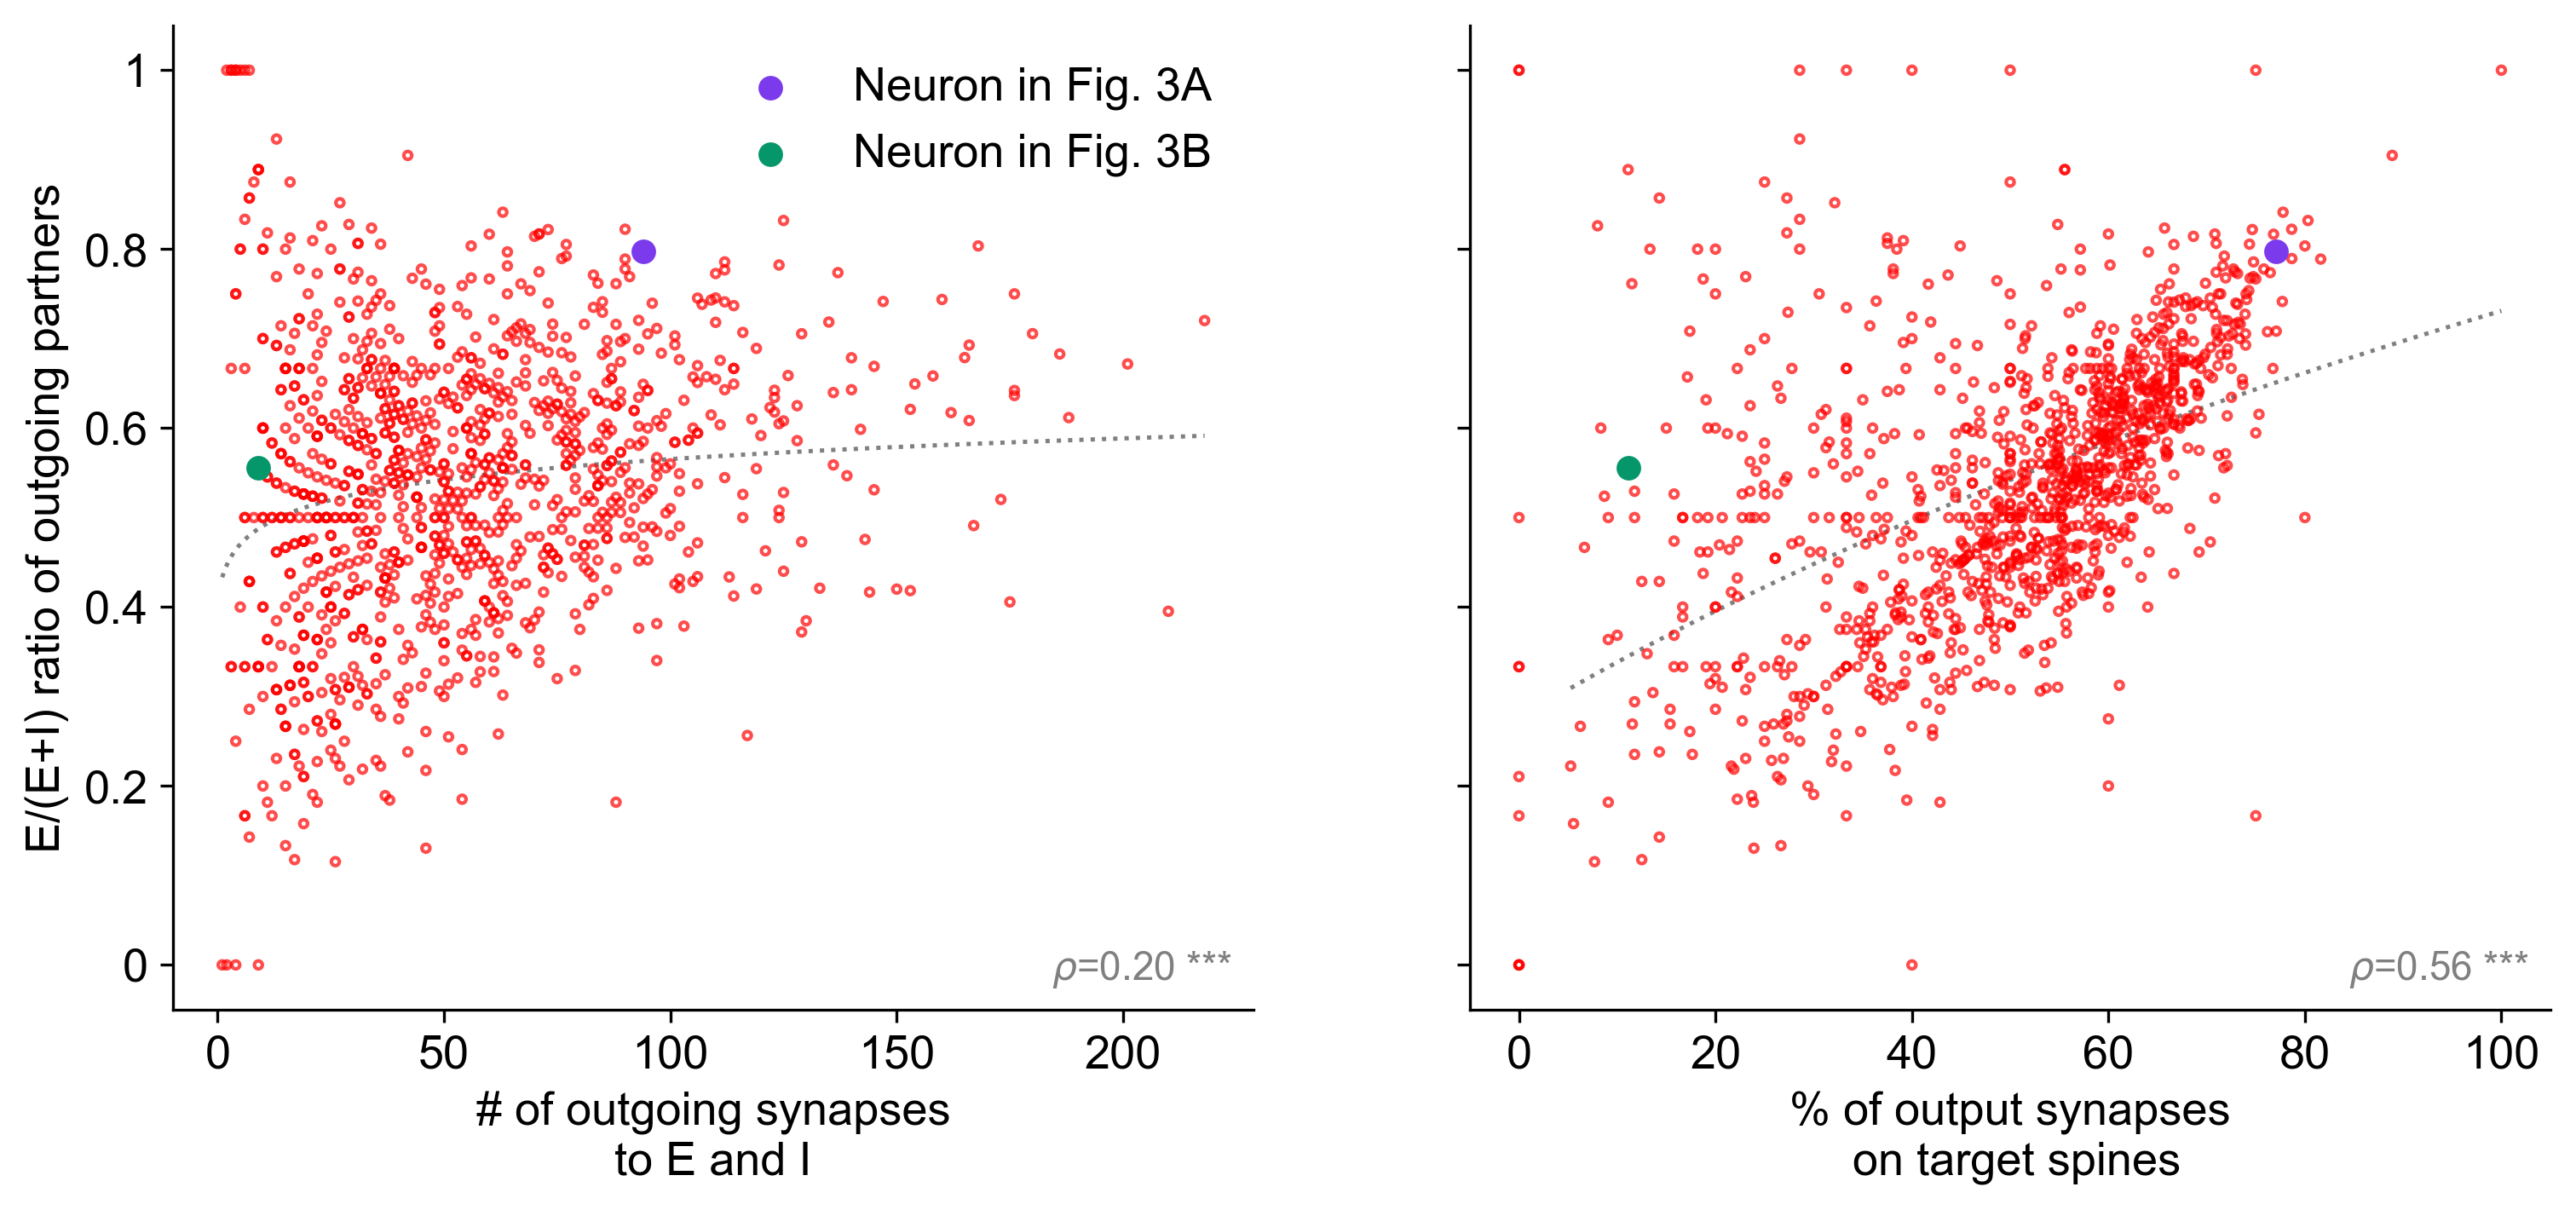

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(6*2, 5), dpi=300, sharey=True)

ax = axes[0]
ax.scatter(x=df_EE['n_syn_to_EI'], y=df_EE['ei_outgoing_ratio_norm'], edgecolors=ex_color,
           facecolors='none', s=5, alpha=0.7, zorder=5)
add_log_curve(df_EE, 'n_syn_to_EI', 'ei_outgoing_ratio_norm', ax=ax, color='gray',
              fontsize=scatter_overlay_fontsize, linestyle=':')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel('# of outgoing synapses\nto E and I')
ax.set_ylabel('E/(E+I) ratio of outgoing partners')

high_deg_neuron = df_EE[df_EE['root_id'] == high_deg_nodes[0]]
low_degree_neuron = df_EE[df_EE['root_id'] == high_deg_nodes[1]]
ax.scatter(x=high_deg_neuron['n_syn_to_EI'], y=high_deg_neuron['ei_outgoing_ratio_norm'],
           color=spiny_color, s=35, zorder=10, label='Neuron in Fig. 3A')
ax.scatter(x=low_degree_neuron['n_syn_to_EI'], y=low_degree_neuron['ei_outgoing_ratio_norm'],
           color=aspiny_color, s=35, zorder=10, label='Neuron in Fig. 3B')
ax.legend(loc='upper right', frameon=False)
ax.yaxis.set_major_formatter(FormatStrFormatter('%g'))

ax = axes[1]
ax.scatter(x=df_EE['outgoing_spine_ratio_all'], y=df_EE['ei_outgoing_ratio_norm'], edgecolors=ex_color,
           facecolors='none', s=5, alpha=0.7, zorder=5)
add_log_curve(df_EE, 'outgoing_spine_ratio_all', 'ei_outgoing_ratio_norm', ax=ax, color='gray',
              fontsize=scatter_overlay_fontsize, linestyle=':')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel('% of output synapses\n on target spines')
ax.xaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0, symbol=''))

ax.scatter(x=high_deg_neuron['outgoing_spine_ratio_all'], y=high_deg_neuron['ei_outgoing_ratio_norm'],
           color=spiny_color, s=35, zorder=10, label='Neuron in Fig. 3A')
ax.scatter(x=low_degree_neuron['outgoing_spine_ratio_all'], y=low_degree_neuron['ei_outgoing_ratio_norm'],
           color=aspiny_color, s=35, zorder=10, label='Neuron in Fig. 3B')

plt.savefig('fig_s6.pdf', format='pdf', bbox_inches='tight')